In [15]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
from collections import Counter

# Always reload from the raw file — never from a previous notebook's memory
# This makes the notebook independently reproducible
df = pd.read_excel("SampleDateExtract.xlsx")

print("Loaded:", df.shape)

Loaded: (1000, 18)


In [16]:
# This is the single most important function in the pipeline
# It safely converts a string like "['Breast Cancer', 'Solid Tumors']"
# into an actual Python list: ['Breast Cancer', 'Solid Tumors']

def safe_parse_list(value):
    # If the cell is null/NaN, return an empty list (not None)
    # This makes downstream code consistent — you always get a list back
    if pd.isna(value):
        return []

    # ast.literal_eval safely evaluates a string as a Python literal
    # It only handles basic types: lists, dicts, strings, numbers
    # It will NEVER execute arbitrary code — unlike eval() which is dangerous
    try:
        result = ast.literal_eval(str(value))
        # Make sure we actually got a list back
        if isinstance(result, list):
            return result
        else:
            return [result]
    except (ValueError, SyntaxError):
        # If parsing fails, return empty list and don't crash
        return []

# Test it on one value before applying to whole column
raw_val = df['indications'].iloc[0]
print("Raw:", repr(raw_val))
print("Parsed:", safe_parse_list(raw_val))
print("Type after parsing:", type(safe_parse_list(raw_val)))

Raw: "['Anorectal Cancer', 'Epithelial Neoplasm']"
Parsed: ['Anorectal Cancer', 'Epithelial Neoplasm']
Type after parsing: <class 'list'>


In [17]:
list_cols = [
    'indications',
    'interventions_drugs',
    'drugs_datalake',
    'main_technologies',
    'specific_technologies',
    'target_names',
    'target_abbreviations'
]

# Apply safe_parse_list to every cell in each of these columns
# We store results in new columns with _parsed suffix
# This preserves the original columns — never overwrite raw data
for col in list_cols:
    df[col + '_parsed'] = df[col].apply(safe_parse_list)

# Verify: show what indications_parsed looks like for first 3 rows
for i in range(4):
    print(f"Row {i}:", df['indications_parsed'].iloc[i])

Row 0: ['Anorectal Cancer', 'Epithelial Neoplasm']
Row 1: ['Thoracic Neoplasm']
Row 2: ['Ovarian Cancer']
Row 3: ['Small Intestinal Adenocarcinoma']


In [18]:
# The technology columns are nested — each element is itself a list
# because each drug in a trial has its own technology type
# Example: [['Small Molecule'], ['Antibody']] — one list per drug
# We need to flatten this to ['Small Molecule', 'Antibody']

print("Raw main_technologies for row 0:")
print(df['main_technologies_parsed'].iloc[0])
print()
print("This is nested — each drug has its own tech list inside")

def flatten_nested_list(nested):
    # Takes [['Small Molecule'], ['Antibody']]
    # Returns ['Small Molecule', 'Antibody']
    result = []
    for item in nested:
        if isinstance(item, list):
            # item is itself a list — extend (add all elements)
            result.extend(item)
        else:
            # item is a plain string — append it directly
            result.append(item)
    # Remove empty strings that sometimes appear
    return [x for x in result if x]

df['main_tech_flat'] = df['main_technologies_parsed'].apply(flatten_nested_list)
df['specific_tech_flat'] = df['specific_technologies_parsed'].apply(flatten_nested_list)
df['target_abbr_flat'] = df['target_abbreviations_parsed'].apply(flatten_nested_list)

# Verify
print("\nAfter flattening row 0:")
print(df['main_tech_flat'].iloc[0])

Raw main_technologies for row 0:
[['Antibody'], ['Small Molecule']]

This is nested — each drug has its own tech list inside

After flattening row 0:
['Antibody', 'Small Molecule']


In [19]:
# The phase column has string values — we need a numeric version
# so we can sort, filter by range, and do arithmetic on phase

# This mapping is a deliberate design decision:
# PHASE1/PHASE2 trials sit between phases — we assign 1.5
# EARLY_PHASE1 is pre-Phase 1 (first-in-human dose finding) — we assign 0.5
phase_map = {
    'EARLY_PHASE1':  0.5,
    'PHASE1':        1.0,
    'PHASE1/PHASE2': 1.5,
    'PHASE2':        2.0,
    'PHASE2/PHASE3': 2.5,
    'PHASE3':        3.0,
    'PHASE4':        4.0
}

df['phase_num'] = df['phase'].map(phase_map)
# Trials with no phase recorded get NaN — which is correct
# We don't impute a fake phase value

print("Phase → phase_num mapping:")
print(df[['phase', 'phase_num']].value_counts().head(10))
print("\nTrials with no phase (phase_num is NaN):", df['phase_num'].isna().sum())

Phase → phase_num mapping:
phase          phase_num
PHASE2         2.0          402
PHASE1         1.0          253
PHASE1/PHASE2  1.5          126
PHASE3         3.0          124
PHASE4         4.0           25
PHASE2/PHASE3  2.5           17
EARLY_PHASE1   0.5           13
Name: count, dtype: int64

Trials with no phase (phase_num is NaN): 40


In [20]:
# Engineer start_year — useful for time-trend analysis
df['start_year'] = df['start_date'].dt.year

# Trial duration in days — completion minus start
# Only defined where both dates exist
df['trial_duration_days'] = (
    df['completion_date'] - df['start_date']
).dt.days

# Sanity check: are there any negative durations?
negative = (df['trial_duration_days'] < 0).sum()
print("Trials with negative duration:", negative)

print("\nDuration stats (days):")
print(df['trial_duration_days'].describe().round(0))

print("\nStart year range:")
print(df['start_year'].min(), "to", df['start_year'].max())

Trials with negative duration: 0

Duration stats (days):
count      946.0
mean      1621.0
std       1142.0
min          0.0
25%        828.0
50%       1352.0
75%       2162.0
max      11137.0
Name: trial_duration_days, dtype: float64

Start year range:
1986.0 to 2026.0


In [21]:
# This is the most important design decision in the whole pipeline
# There is no success column — we must define success ourselves

# We map each recruitment_status to one of 5 outcome categories:
# success   → trial ran to protocol completion
# failure   → trial stopped before completion
# ongoing   → trial is still running (exclude from rate calculation)
# pending   → trial hasn't started yet (exclude)
# ambiguous → no status update available (exclude)

outcome_map = {
    'COMPLETED':              'success',
    'TERMINATED':             'failure',
    'WITHDRAWN':              'failure',
    'SUSPENDED':              'failure',
    'RECRUITING':             'ongoing',
    'ACTIVE_NOT_RECRUITING':  'ongoing',
    'ENROLLING_BY_INVITATION':'ongoing',
    'NOT_YET_RECRUITING':     'pending',
    'UNKNOWN':                'ambiguous'
}

df['outcome_label'] = df['recruitment_status'].map(outcome_map)

print("Outcome distribution:")
print(df['outcome_label'].value_counts())
print("\nTotal resolved (success + failure):",
      df['outcome_label'].isin(['success','failure']).sum())

Outcome distribution:
outcome_label
success      453
ongoing      218
failure      167
ambiguous    121
pending       41
Name: count, dtype: int64

Total resolved (success + failure): 620


In [22]:
# For mathematical rate calculations we need a 0/1 column
# success  → 1
# failure  → 0
# everything else (ongoing/pending/ambiguous) → NaN
#
# NaN here is INTENTIONAL — it means "not yet resolved"
# When we compute success rates, we'll use .mean() which
# automatically skips NaN values

binary_map = {'success': 1, 'failure': 0}
df['success_binary'] = df['outcome_label'].map(binary_map)

# Verify the counts make sense
print("success_binary value counts:")
print(df['success_binary'].value_counts(dropna=False))

print("\nOverall process success rate (resolved trials only):")
rate = df['success_binary'].mean() * 100  # .mean() skips NaN automatically
print(f"{rate:.1f}%")

print("\nDenominator (resolved trials):", df['success_binary'].notna().sum())
print("Total trials:", len(df))

success_binary value counts:
success_binary
1.0    453
NaN    380
0.0    167
Name: count, dtype: int64

Overall process success rate (resolved trials only):
73.1%

Denominator (resolved trials): 620
Total trials: 1000


In [23]:
# Now we explode the multi-valued columns into separate DataFrames
# This is the normalisation step — turning one wide row into many narrow rows

# --- Child table 1: trial_indications ---
# Each trial can have multiple indications
# We explode so each indication gets its own row

trial_indications = df[['nct_id', 'indications_parsed']].copy()
trial_indications = trial_indications.explode('indications_parsed')
trial_indications.columns = ['nct_id', 'indication']
# Drop rows where indication is empty string or None
trial_indications = trial_indications[
    trial_indications['indication'].notna() &
    (trial_indications['indication'] != '')
].reset_index(drop=True)

print("trial_indications shape:", trial_indications.shape)
print(trial_indications.head(5))

trial_indications shape: (2231, 2)
        nct_id                       indication
0  NCT06669572                 Anorectal Cancer
1  NCT06669572              Epithelial Neoplasm
2  NCT06883552                Thoracic Neoplasm
3  NCT06366490                   Ovarian Cancer
4  NCT06835387  Small Intestinal Adenocarcinoma


In [24]:
# --- Child table 2: trial_drugs ---
trial_drugs = df[['nct_id', 'interventions_drugs_parsed']].copy()
trial_drugs = trial_drugs.explode('interventions_drugs_parsed')
trial_drugs.columns = ['nct_id', 'drug_name']
trial_drugs = trial_drugs[
    trial_drugs['drug_name'].notna() &
    (trial_drugs['drug_name'] != '')
].reset_index(drop=True)

print("trial_drugs shape:", trial_drugs.shape)
print(trial_drugs.head(5))

# What are the most common drugs across all trials?
print("\nTop 10 most frequent drugs:")
print(trial_drugs['drug_name'].value_counts().head(10))

trial_drugs shape: (2716, 2)
        nct_id               drug_name
0  NCT06669572           Pembrolizumab
1  NCT06669572              Lenvatinib
2  NCT06883552            Tislelizumab
3  NCT06366490                Innocell
4  NCT06835387  Irinotecan Sucrosofate

Top 10 most frequent drugs:
drug_name
Cyclophosphamide     59
Cisplatin            57
Carboplatin          55
Paclitaxel           55
Gemcitabine          48
Placebo Control      48
Docetaxel            41
Oxaliplatin          39
Radiation Therapy    37
Fluorouracil         36
Name: count, dtype: int64


In [25]:
# --- Child table 3: trial_technologies ---
trial_tech = df[['nct_id', 'main_tech_flat']].copy()
trial_tech = trial_tech.explode('main_tech_flat')
trial_tech.columns = ['nct_id', 'technology']
trial_tech = trial_tech[
    trial_tech['technology'].notna() &
    (trial_tech['technology'] != '')
].reset_index(drop=True)

print("trial_technologies shape:", trial_tech.shape)
print("\nTechnology value counts:")
print(trial_tech['technology'].value_counts())

trial_technologies shape: (1966, 2)

Technology value counts:
technology
Small Molecule                                                             1446
Antibody                                                                    324
Other Protein Therapy                                                        61
Antibody Drug Conjugate (ADC)                                                22
Engineered Protein Therapy                                                   21
Radiopharmaceutical Imaging                                                  15
Chimeric Antigen Receptor T-Cell Therapy (CAR-T)                             15
Cancer Vaccine                                                                9
Imaging                                                                       7
Cell Therapy                                                                  6
Subunit Vaccine                                                               4
Live biotherapeutics                           

In [26]:
# Define the clean set of columns for the core table
core_cols = [
    'nct_id', 'ID-datalake', 'brief_title',
    'phase', 'phase_num',
    'recruitment_status', 'outcome_label', 'success_binary',
    'start_date', 'completion_date', 'primary_completion_date',
    'start_year', 'trial_duration_days',
    'enrollment', 'enrollment_type'
]

clean_core = df[core_cols].copy()

# Save everything
clean_core.to_csv("clean_trials.csv", index=False)
trial_indications.to_csv("trial_indications.csv", index=False)
trial_drugs.to_csv("trial_drugs.csv", index=False)
trial_tech.to_csv("trial_technologies.csv", index=False)

print("Saved:")
print(f"  clean_trials.csv        — {clean_core.shape[0]} rows, {clean_core.shape[1]} cols")
print(f"  trial_indications.csv   — {trial_indications.shape[0]} rows")
print(f"  trial_drugs.csv         — {trial_drugs.shape[0]} rows")
print(f"  trial_technologies.csv  — {trial_tech.shape[0]} rows")

Saved:
  clean_trials.csv        — 1000 rows, 15 cols
  trial_indications.csv   — 2231 rows
  trial_drugs.csv         — 2716 rows
  trial_technologies.csv  — 1966 rows


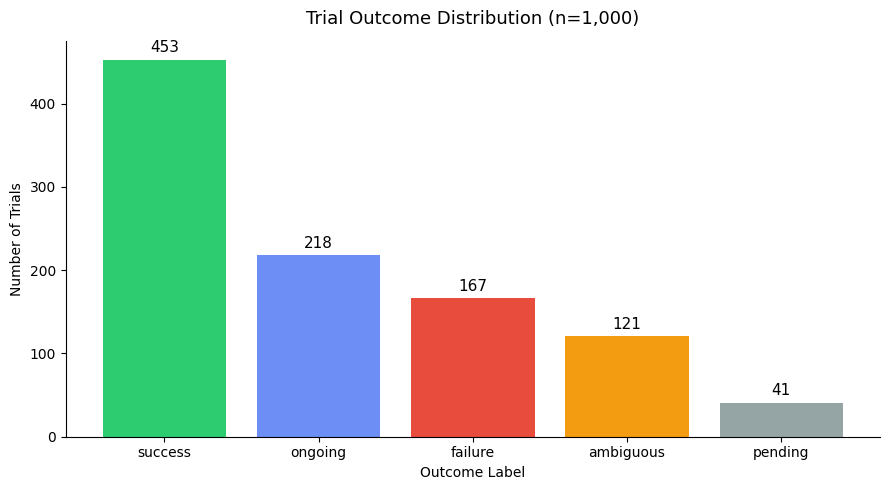


Process success rate among resolved trials: 73.1%


In [27]:
# Plot outcome distribution — this goes in your README
outcome_counts = df['outcome_label'].value_counts()

colors = {
    'success': '#2ecc71',
    'failure': '#e74c3c',
    'ongoing': '#6c8ef5',
    'ambiguous': '#f39c12',
    'pending': '#95a5a6'
}

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    outcome_counts.index,
    outcome_counts.values,
    color=[colors[x] for x in outcome_counts.index],
    edgecolor='none'
)

# Add count labels on top of each bar
for bar, val in zip(bars, outcome_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontsize=11)

ax.set_title("Trial Outcome Distribution (n=1,000)", fontsize=13, pad=12)
ax.set_ylabel("Number of Trials")
ax.set_xlabel("Outcome Label")
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig("outcome_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nProcess success rate among resolved trials:",
      f"{df['success_binary'].mean()*100:.1f}%")

In [30]:
%cd /content

!git clone https://github.com/akblue289/i3_clinical.git

/content
Cloning into 'i3_clinical'...
remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 17 (delta 1), reused 13 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (17/17), 549.31 KiB | 4.22 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [31]:
%cd /content/i3_clinical

!git status

/content/i3_clinical
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [32]:
!cp /content/clean_trials.csv /content/i3_clinical/
!cp /content/trial_indications.csv /content/i3_clinical/
!cp /content/trial_drugs.csv /content/i3_clinical/
!cp /content/trial_technologies.csv /content/i3_clinical/
!cp /content/outcome_distribution.png /content/i3_clinical/

In [33]:
%cd /content/i3_clinical

!git add notebooks/02_schema_cleaning.ipynb

!git add clean_trials.csv trial_indications.csv trial_drugs.csv trial_technologies.csv

!git add outcome_distribution.png

!git commit -m "Part 1B + 2A: schema normalisation, outcome labelling, success proxy definition"

!git push origin main

/content/i3_clinical
fatal: pathspec 'notebooks/02_schema_cleaning.ipynb' did not match any files
Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@acfa9af78b8b.(none)')
fatal: could not read Username for 'https://github.com': No such device or address


In [36]:
!mkdir -p /content/i3_clinical/notebooks